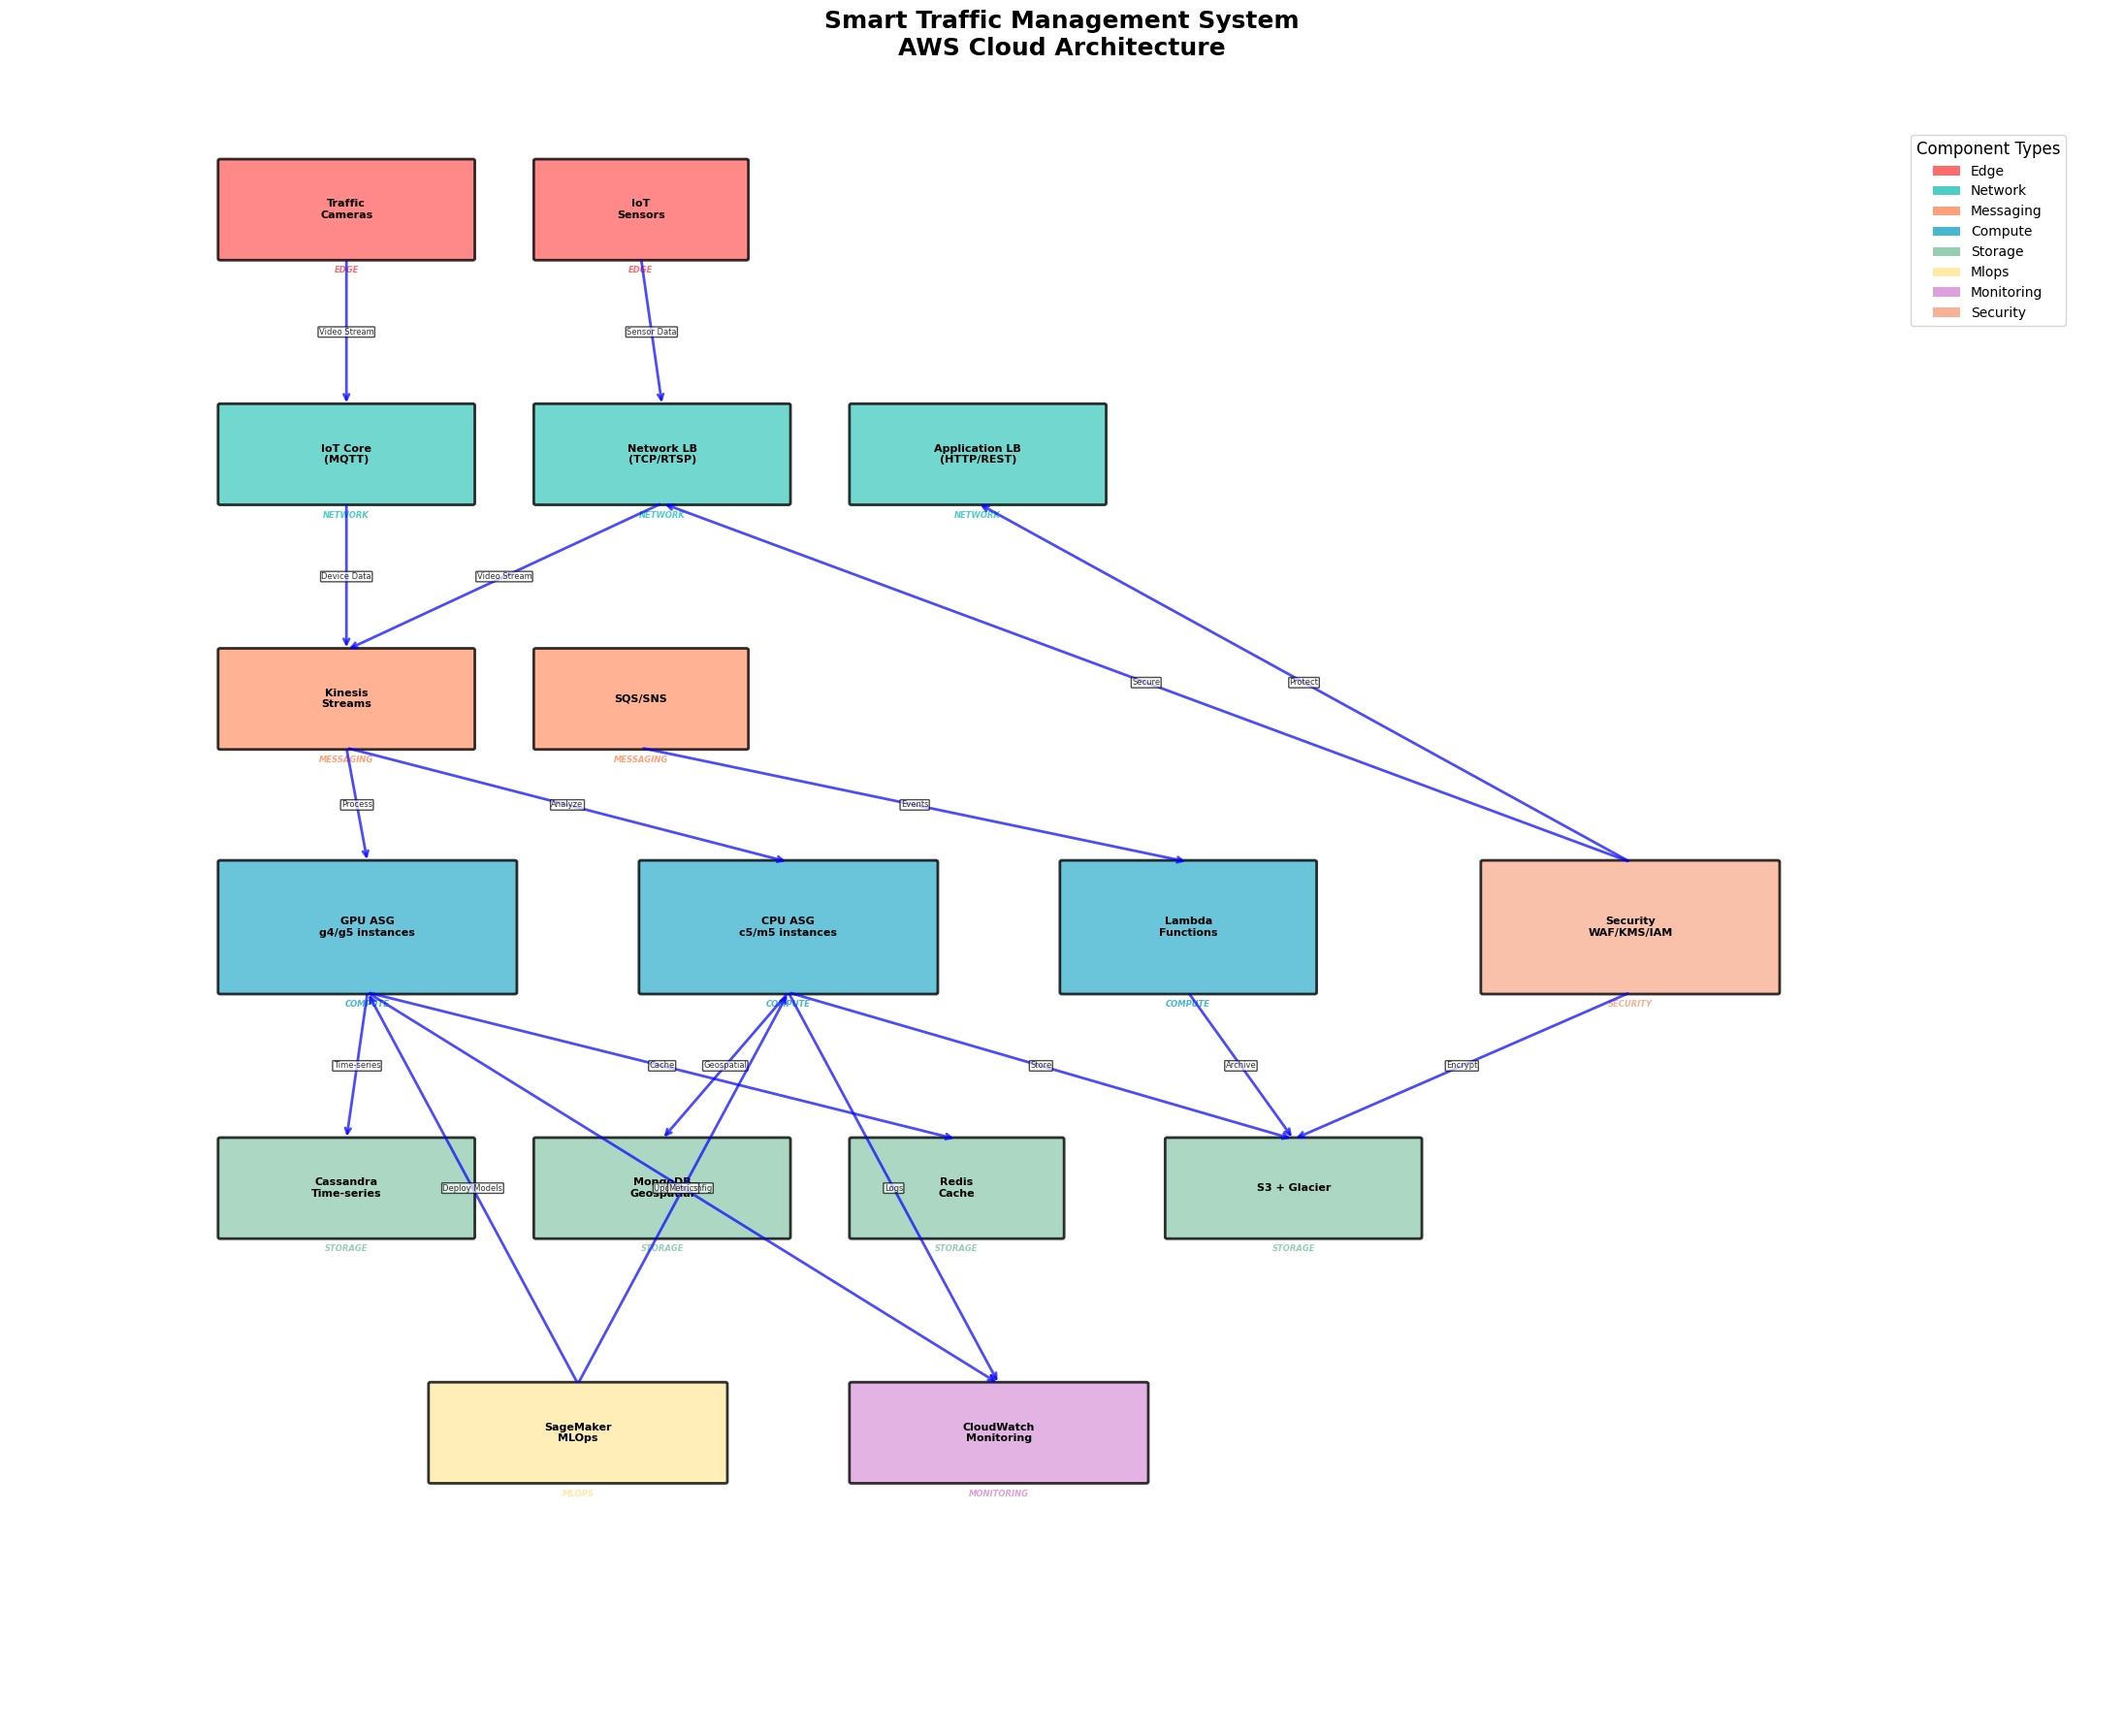


🏗️ ARCHITECTURE INSIGHTS:

🔹 DATA FLOW:
   Edge Devices → Message Queues → Compute Tier → Storage & Databases

🔹 SCALING STRATEGY:
   • Horizontal: Auto Scaling Groups (preferred)
   • GPU/CPU separation for cost optimization
   • Metrics-driven auto-scaling

🔹 DATABASE SELECTION:
   • Cassandra: Time-series, high-write traffic data
   • MongoDB: Geospatial queries, flexible schema
   • Redis: Real-time caching, low-latency access

🔹 SECURITY:
   • Defense in depth with WAF, KMS, IAM
   • Network segmentation with VPC
   • Encryption at rest and in transit

🔹 COST OPTIMIZATION:
   • Spot instances for batch processing
   • Lifecycle policies for S3 → Glacier
   • Right-sizing instances based on workload



In [7]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.patches import FancyBboxPatch, Circle
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
import numpy as np
import matplotlib.image as mpimg

def create_enhanced_architecture_diagram():
    fig, ax = plt.subplots(1, 1, figsize=(22, 18))
    ax.set_xlim(0, 100)
    ax.set_ylim(0, 100)
    ax.axis('off')
    
    # Define component positions and properties
    components = [
        # Edge Layer
        {"name": "Traffic\nCameras", "type": "edge", "pos": (10, 90), "size": (12, 6)},
        {"name": "IoT\nSensors", "type": "edge", "pos": (25, 90), "size": (10, 6)},
        
        # Network Layer
        {"name": "IoT Core\n(MQTT)", "type": "network", "pos": (10, 75), "size": (12, 6)},
        {"name": "Network LB\n(TCP/RTSP)", "type": "network", "pos": (25, 75), "size": (12, 6)},
        {"name": "Application LB\n(HTTP/REST)", "type": "network", "pos": (40, 75), "size": (12, 6)},
        
        # Messaging Layer
        {"name": "Kinesis\nStreams", "type": "messaging", "pos": (10, 60), "size": (12, 6)},
        {"name": "SQS/SNS", "type": "messaging", "pos": (25, 60), "size": (10, 6)},
        
        # Compute Layer
        {"name": "GPU ASG\ng4/g5 instances", "type": "compute", "pos": (10, 45), "size": (14, 8)},
        {"name": "CPU ASG\nc5/m5 instances", "type": "compute", "pos": (30, 45), "size": (14, 8)},
        {"name": "Lambda\nFunctions", "type": "compute", "pos": (50, 45), "size": (12, 8)},
        
        # Storage Layer
        {"name": "Cassandra\nTime-series", "type": "storage", "pos": (10, 30), "size": (12, 6)},
        {"name": "MongoDB\nGeospatial", "type": "storage", "pos": (25, 30), "size": (12, 6)},
        {"name": "Redis\nCache", "type": "storage", "pos": (40, 30), "size": (10, 6)},
        {"name": "S3 + Glacier", "type": "storage", "pos": (55, 30), "size": (12, 6)},
        
        # MLOps & Monitoring
        {"name": "SageMaker\nMLOps", "type": "mlops", "pos": (20, 15), "size": (14, 6)},
        {"name": "CloudWatch\nMonitoring", "type": "monitoring", "pos": (40, 15), "size": (14, 6)},
        
        # Security
        {"name": "Security\nWAF/KMS/IAM", "type": "security", "pos": (70, 45), "size": (14, 8)},
    ]
    
    # Color scheme
    colors = {
        'edge': '#FF6B6B',      # Red
        'network': '#4ECDC4',   # Teal
        'messaging': '#FFA07A', # Light Salmon
        'compute': '#45B7D1',   # Blue
        'storage': '#96CEB4',   # Green
        'mlops': '#FFEAA7',     # Yellow
        'monitoring': '#DDA0DD', # Plum
        'security': '#F8B195'   # Orange
    }
    
    # Draw components
    for comp in components:
        x, y = comp["pos"]
        w, h = comp["size"]
        color = colors[comp["type"]]
        
        # Create rounded rectangle
        rect = FancyBboxPatch((x, y), w, h,
                             boxstyle="round,pad=0.1",
                             facecolor=color,
                             edgecolor='black',
                             alpha=0.8,
                             linewidth=2)
        ax.add_patch(rect)
        
        # Add text
        ax.text(x + w/2, y + h/2, comp["name"], 
               ha='center', va='center', 
               fontsize=8, fontweight='bold',
               wrap=True)
        
        # Add component type label
        ax.text(x + w/2, y - 1, comp["type"].upper(), 
               ha='center', va='bottom', 
               fontsize=6, fontweight='bold',
               color=color, style='italic')
    
    # Define data flows
    connections = [
        # Edge to Network
        ((10, 90), (10, 75), "Video Stream"),  # Cameras -> IoT Core
        ((25, 90), (25, 75), "Sensor Data"),   # Sensors -> NLB
        
        # Network to Messaging
        ((10, 75), (10, 60), "Device Data"),   # IoT Core -> Kinesis
        ((25, 75), (10, 60), "Video Stream"),  # NLB -> Kinesis
        
        # Messaging to Compute
        ((10, 60), (10, 45), "Process"),       # Kinesis -> GPU ASG
        ((10, 60), (30, 45), "Analyze"),       # Kinesis -> CPU ASG
        ((25, 60), (50, 45), "Events"),        # SQS -> Lambda
        
        # Compute to Storage
        ((10, 45), (10, 30), "Time-series"),   # GPU -> Cassandra
        ((30, 45), (25, 30), "Geospatial"),    # CPU -> MongoDB
        ((10, 45), (40, 30), "Cache"),         # GPU -> Redis
        ((30, 45), (55, 30), "Store"),         # CPU -> S3
        ((50, 45), (55, 30), "Archive"),       # Lambda -> S3
        
        # MLOps & Monitoring
        ((20, 15), (10, 45), "Deploy Models"), # SageMaker -> GPU
        ((20, 15), (30, 45), "Update Config"), # SageMaker -> CPU
        ((10, 45), (40, 15), "Metrics"),       # GPU -> CloudWatch
        ((30, 45), (40, 15), "Logs"),          # CPU -> CloudWatch
        
        # Security
        ((70, 45), (40, 75), "Protect"),       # Security -> ALB
        ((70, 45), (25, 75), "Secure"),        # Security -> NLB
        ((70, 45), (55, 30), "Encrypt"),       # Security -> S3
    ]
    
    # Draw connections with arrows
    for (start_comp, end_comp, label) in connections:
        start_idx = next(i for i, c in enumerate(components) if c["pos"] == start_comp)
        end_idx = next(i for i, c in enumerate(components) if c["pos"] == end_comp)
        
        start = components[start_idx]
        end = components[end_idx]
        
        x1, y1 = start["pos"]
        w1, h1 = start["size"]
        x2, y2 = end["pos"]
        w2, h2 = end["size"]
        
        # Calculate connection points
        start_x = x1 + w1/2
        start_y = y1 if y1 > y2 else y1 + h1  # Connect from top if going up, bottom if going down
        end_x = x2 + w2/2
        end_y = y2 + h2 if y1 > y2 else y2    # Connect to bottom if coming from above, top if below
        
        # Draw arrow
        ax.annotate('', xy=(end_x, end_y), xytext=(start_x, start_y),
                   arrowprops=dict(arrowstyle='->', lw=2, color='blue', alpha=0.7))
        
        # Add connection label
        mid_x = (start_x + end_x) / 2
        mid_y = (start_y + end_y) / 2
        ax.text(mid_x, mid_y, label, ha='center', va='center', 
                fontsize=6, backgroundcolor='white', alpha=0.8,
                bbox=dict(boxstyle="round,pad=0.1", facecolor='white', alpha=0.7))
    
    # Add title and legend
    plt.title('Smart Traffic Management System\nAWS Cloud Architecture', 
              fontsize=18, fontweight='bold', pad=30)
    
    # Add legend
    legend_elements = []
    for comp_type, color in colors.items():
        legend_elements.append(plt.Rectangle((0,0),1,1, facecolor=color, label=comp_type.title()))
    
    ax.legend(handles=legend_elements, loc='upper right', bbox_to_anchor=(0.98, 0.98),
              fontsize=10, title="Component Types", title_fontsize=12)
    
    plt.tight_layout()
    return fig

# Generate the enhanced diagram
fig = create_enhanced_architecture_diagram()
plt.show()

# Print architecture insights
print("""
🏗️ ARCHITECTURE INSIGHTS:

🔹 DATA FLOW:
   Edge Devices → Message Queues → Compute Tier → Storage & Databases

🔹 SCALING STRATEGY:
   • Horizontal: Auto Scaling Groups (preferred)
   • GPU/CPU separation for cost optimization
   • Metrics-driven auto-scaling

🔹 DATABASE SELECTION:
   • Cassandra: Time-series, high-write traffic data
   • MongoDB: Geospatial queries, flexible schema
   • Redis: Real-time caching, low-latency access

🔹 SECURITY:
   • Defense in depth with WAF, KMS, IAM
   • Network segmentation with VPC
   • Encryption at rest and in transit

🔹 COST OPTIMIZATION:
   • Spot instances for batch processing
   • Lifecycle policies for S3 → Glacier
   • Right-sizing instances based on workload
""")